# SkylineGeolocation — Avenue A/B/C GPU Evaluation

Tests three avenues that require GPU:
- **Avenue A**: SAM 2 zero-shot sky segmentation (full-res 1080×720 masks)
- **Avenue B**: DINOv2 ViT-S/14 feature matching (2D vision-transformer cosine similarity)
- **Avenue C**: PnP RANSAC peak constellation (already tested locally — loaded from Drive)

**All checkpoints saved to `MyDrive/avenue_checkpoints/`. Re-run skips completed work.**

Required Drive files:
- `MyDrive/skyline_db.parquet`
- `MyDrive/street_view/` (images/, masks/, ground_truth.json, annotations.json)
- `MyDrive/sky_segmentation_unet_model.pth`

GPU: T4 (16GB) recommended. Avenue A+B take ~20 min total.

## 1. Setup

In [2]:
import os, shutil
from pathlib import Path

REPO = Path('/content/SkylineGeolocation')
BRANCH = 'main'

if (REPO / 'src').exists():
    print('Repo already at', REPO)
else:
    print('Cloning repo...')
    if REPO.is_file() or REPO.is_symlink():
        REPO.unlink()
    elif REPO.is_dir():
        shutil.rmtree(REPO)
    REPO.parent.mkdir(parents=True, exist_ok=True)
    import subprocess
    subprocess.run(
        ['git', 'clone', '--depth', '1', '-b', BRANCH,
         'https://github.com/pxrxp/SkylineGeolocation.git', str(REPO)],
        check=True, capture_output=True, text=True
    )
    print('Cloned. Branch:', BRANCH)
import sys
sys.path.insert(0, str(REPO))

Cloning repo...
Cloned. Branch: main


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('Drive mounted at /content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive


In [4]:
!pip install -q timm torchvision fastdtw pyarrow geopy
!apt-get install -qq libgl1-mesa-glx libglib2.0-0 2>/dev/null

# SAM 2 install — skip if already available
try:
    import sam2; print('SAM 2 already installed')
except ImportError:
    print('Installing SAM 2...')
    !pip install -q git+https://github.com/facebookresearch/sam2.git

print('Deps ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installing SAM 2...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.1 MB/s eta 0:00:00
Deps ready


In [5]:
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive')
CKPT_DIR = DRIVE / 'avenue_checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
STATE_PATH = CKPT_DIR / 'state.json'

links = [
    (DRIVE / 'skyline_db.parquet',
     REPO / 'notebooks/02_SkylineDatabase/output/skyline_db.parquet'),
    (DRIVE / 'street_view',
     REPO / 'data/street_view'),
    (DRIVE / 'sky_segmentation_unet_model.pth',
     REPO / 'data/sky_segmentation_unet_model.pth'),
]

for src, dst in links:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists() and src.exists():
        os.symlink(src, dst)
        print(f'Linked {src.name}')
    elif dst.exists():
        print(f'{dst.name}: already linked')
    else:
        print(f'MISSING: {src}')

Linked skyline_db.parquet
Linked street_view
sky_segmentation_unet_model.pth: already linked


In [6]:
db_path = REPO / 'notebooks/02_SkylineDatabase/output/skyline_db.parquet'
if db_path.exists():
    size_mb = db_path.stat().st_size / 1024 / 1024
    with open(db_path, 'rb') as f:
        f.seek(0); hdr = f.read(4)
        f.seek(-8, 2); ftr = f.read()
    valid = hdr == b'PAR1' and ftr[:4] == b'PAR1'
    print(f'DB: {size_mb:.0f}MB, valid={valid}')
else:
    print('DB MISSING — cannot proceed')

DB: 463MB, valid=False


In [7]:
import json, time
from pathlib import Path

class CheckpointManager:
    """Per-sample checkpointing to Drive. Crash-safe: state written after each sample."""
    def __init__(self, state_path):
        self.path = Path(state_path)
        self.state = {}
        if self.path.exists():
            try:
                self.state = json.loads(self.path.read_text())
            except (json.JSONDecodeError, OSError):
                self.state = {}
    def is_done(self, avenue, sample_id):
        return self.state.get(avenue, {}).get(sample_id, {}).get('status') == 'ok'
    def mark_done(self, avenue, sample_id, **meta):
        self.state.setdefault(avenue, {})[sample_id] = {
            'status': 'ok', 'time': time.strftime('%Y-%m-%d %H:%M:%S'), **meta
        }
        self.save()
    def save(self):
        self.path.parent.mkdir(parents=True, exist_ok=True)
        tmp = self.path.with_suffix('.tmp')
        tmp.write_text(json.dumps(self.state, indent=2, default=str))
        tmp.rename(self.path)  # atomic on same filesystem
    def summary(self):
        for ave in self.state:
            done = sum(1 for v in self.state[ave].values() if v.get('status') == 'ok')
            total = len(self.state[ave])
            print(f'  {ave}: {done}/{total} samples completed')

ck = CheckpointManager(STATE_PATH)
print('Checkpoint state:')
ck.summary() if ck.state else print('  Fresh start')

Checkpoint state:
  Fresh start


## 2. Avenue A: SAM 2 Zero-Shot Sky Segmentation

Replace U-Net 256×256 masks with SAM 2 full-res 1080×720 masks.
Point prompts at top of frame (sky) + bottom (terrain).

In [24]:
import json, os, sys, time
import numpy as np
from pathlib import Path
from PIL import Image

sys.path.insert(0, str(REPO))
from src.query_profile import extract_elevation_profile
from scripts.fixes_eval import Rx, mask_from_ann, DB_PATH, GT_FILE, ANNOT_FILE, CALIB_FILE

IMAGE_DIR = REPO / 'data/street_view/images'
MASK_DIR_A = CKPT_DIR / 'avenue_a_masks'
PROFILE_DIR_A = CKPT_DIR / 'avenue_a_profiles'
MASK_DIR_A.mkdir(parents=True, exist_ok=True)
PROFILE_DIR_A.mkdir(parents=True, exist_ok=True)

gt = json.load(open(REPO / 'data/street_view/ground_truth.json'))
ann = json.load(open(REPO / 'data/street_view/annotations.json'))['annotations']
calib = json.load(open(REPO / 'data/street_view/calibrated_ground_truth.json'))
sids = [s for s in ann if s in gt and (IMAGE_DIR / f'{s}.png').exists()][:17]
print(f'Samples: {len(sids)}')

need_a = [s for s in sids if not ck.is_done('avenue_a', s)]
print(f'Avenue A remaining: {len(need_a)}/{len(sids)}')

if need_a:
    import torch
    from hydra import compose, initialize_config_dir
    from hydra.core.global_hydra import GlobalHydra
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    # Download weights if missing
    ckpt_path = Path('sam2_hiera_large.pt')
    if not ckpt_path.exists():
        import urllib.request
        url = 'https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt'
        print(f'Downloading SAM2.1 Large weights...')
        urllib.request.urlretrieve(url, ckpt_path)
        print(f'Downloaded: {ckpt_path.stat().st_size / 1e6:.1f} MB')

    # Initialize Hydra with the configs/ subdirectory directly
    import sam2
    sam2_dir = str(Path(sam2.__file__).parent)
    configs_dir = os.path.join(sam2_dir, 'configs')

    GlobalHydra.instance().clear()
    initialize_config_dir(config_dir=configs_dir, version_base=None)
    sam2_model = build_sam2(
        'sam2.1/sam2.1_hiera_l',
        str(ckpt_path),
        device=str(device)
    )
    GlobalHydra.instance().clear()
    predictor = SAM2ImagePredictor(sam2_model)

    for si, sid in enumerate(need_a):
        t0 = time.time()
        g = gt[sid]
        img = np.array(Image.open(IMAGE_DIR / f'{sid}.png').convert('RGB'))
        H, W = img.shape[:2]

        predictor.set_image(img)

        # Point prompts: sky at top center, terrain at bottom center + corners
        pts = np.array([[W//2, 5], [W//2, H-5], [5, H-5], [W-5, H-5]])
        labels = np.array([1, 0, 0, 0])  # 1=sky, 0=terrain

        masks, scores, _ = predictor.predict(
            point_coords=pts,
            point_labels=labels,
            multimask_output=False
        )
        mask = masks[0]  # (H, W) - may be torch tensor or numpy bool

        # Convert to numpy bool if torch tensor
        if hasattr(mask, 'cpu'):
            mask = mask.cpu().numpy()
        mask = mask.astype(bool)

        # Invert: SAM2 mask sky=True -> need sky=255 for extract_elevation_profile convention
        mask_u8 = (~mask).astype(np.uint8) * 255  # sky=255, terrain=0

        # Save mask
        mask_path = MASK_DIR_A / f'{sid}.png'
        Image.fromarray(mask_u8).save(mask_path)

        # Extract profile using r_tilt (rotation matrix) from ground truth
        tilt = np.array(g['cam_R_tilt'])
        dp = float(calib.get(sid, {}).get('delta_pitch_deg', 0.0))
        # Apply pitch calibration: rotate by Rx(dp)
        if dp != 0.0:
            tilt = Rx(np.radians(dp)) @ tilt
        result = extract_elevation_profile(
            mask_u8, fov_y_deg=g['fov_y_deg'], r_tilt=tilt, bin_deg=0.5
        )
        profile_path = PROFILE_DIR_A / f'{sid}.npy'
        np.save(profile_path, result['profile'])

        ck.mark_done('avenue_a', sid)
        dt = time.time() - t0
        print(f'  [{si+1}/{len(need_a)}] {sid} score={scores[0]:.3f} {dt:.1f}s')

    del predictor, sam2_model
    torch.cuda.empty_cache()
    print('Avenue A complete.')
else:
    print('Avenue A already done.')


Samples: 17
Avenue A remaining: 17/17
Device: cuda
  [1/17] gtM1wHN3PY6ExdUpm_Kwxg score=0.992 1.2s
  [2/17] 7MjMNO0rcwbYlY0p0BbpZQ score=0.788 0.7s
  [3/17] 2d-jydcZQqi4LqAfXTTkGg score=0.984 0.7s
  [4/17] zkD6q2a9bU6jrCnCClr2VA score=0.989 0.7s
  [5/17] sLA2BviEGB1J0cWD9M25WA score=0.930 0.7s
  [6/17] CIHM0ogKEICAgIC6rYembA score=0.973 0.7s
  [7/17] CIHM0ogKEICAgIC6rYfGdw score=0.986 0.7s
  [8/17] Ofjf1ddyJ-EgeuduO3MIwA score=0.976 0.7s
  [9/17] MW24IuujFMDM2RjVTsVBFA score=0.472 0.7s
  [10/17] CIHM0ogKEICAgIC6rafUbQ score=0.988 0.7s
  [11/17] fxs4Vz2Y_jxf90ojEuemjQ score=0.833 0.8s
  [12/17] pc2xH30aP_n7tatAMCm0Qg score=0.960 0.8s
  [13/17] 4AQK-ijaR3ZiCtgy_PKW1g score=0.990 0.8s
  [14/17] ovVTNcM4FYYVEcEWX-Bmlg score=0.738 0.8s
  [15/17] rd3ozgCa3b9A94QaOFstLA score=0.935 0.8s
  [16/17] IJWw-IWxZJ1j0X5GhaTWPw score=0.000 0.8s
  [17/17] Huvxci3kfiIGJ9485Hxpkg score=0.111 0.7s
Avenue A complete.


## 3. Avenue B: DINOv2 Feature Matching

Encode query photos + DB horizon silhouette images with DINOv2 ViT-S/14.
Compare cosine similarity to rank candidate VPs.

In [26]:
import json, os, sys, time
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from PIL import Image
from geopy.distance import geodesic
import torch
from torchvision import transforms as T

sys.path.insert(0, str(REPO))
from src.horizon_format import decode_horizon_uint8
from scripts.fixes_eval import Rx, DB_PATH, GT_FILE, ANNOT_FILE, CALIB_FILE

IMAGE_DIR = REPO / 'data/street_view/images'

# Load geometry
meta = pd.read_parquet(DB_PATH, columns=['lon', 'lat'])
vp_lon = meta['lon'].to_numpy()
vp_lat = meta['lat'].to_numpy()
del meta

gt = json.load(open(REPO / 'data/street_view/ground_truth.json'))
ann = json.load(open(REPO / 'data/street_view/annotations.json'))['annotations']
calib = json.load(open(REPO / 'data/street_view/calibrated_ground_truth.json'))
sids = [s for s in ann if s in gt and (IMAGE_DIR / f'{s}.png').exists()][:17]
need_b = [s for s in sids if not ck.is_done('avenue_b', s)]
print(f'Avenue B remaining: {len(need_b)}/{len(sids)}')

RESULTS_DIR_B = CKPT_DIR / 'avenue_b_results'
RESULTS_DIR_B.mkdir(parents=True, exist_ok=True)

if need_b:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True)
    dino_model = dino_model.to(device).eval()
    dino_transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def horizon_to_silhouette(horizon, W=224, H=224):
        L = len(horizon)
        img = np.zeros((H, W), dtype=np.uint8)
        for c in range(W):
            col_az = (c / W) * 360.0
            h_idx = int((col_az % 360.0) / (360.0 / L)) % L
            elev = horizon[h_idx]
            row = int(H * (1.0 - (elev + 10.0) / 100.0))
            row = max(0, min(H - 1, row))
            img[row:, c] = 255
        return img

    def encode_batch(images):
        tensors = []
        for img in images:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            tensors.append(dino_transform(img))
        batch = torch.stack(tensors).to(device)
        with torch.no_grad():
            feats = dino_model(batch)
        return feats.cpu().numpy()

    # Pre-encode DB horizon silhouettes in batches (stride to fit memory)
    DB_STRIDE = 12
    print(f'Encoding DB horizons (stride={DB_STRIDE})...', flush=True)
    t0 = time.time()

    # First pass: count total
    pf = pq.ParquetFile(DB_PATH)
    total_rows = sum(batch.num_rows for batch in pf.iter_batches(batch_size=1, columns=['raw_horizon_deg']))
    n_selected = total_rows // DB_STRIDE
    print(f'Total VPs: {total_rows}, selected: {n_selected}')

    # Encode in batches
    db_feats = []
    db_indices = []
    batch_imgs = []
    batch_idx = []
    BATCH_SIZE = 64
    row_count = 0

    for batch in pf.iter_batches(batch_size=4096, columns=['raw_horizon_deg']):
        for local_i in range(batch.num_rows):
            if row_count % DB_STRIDE != 0:
                row_count += 1
                continue
            horizon = decode_horizon_uint8(batch['raw_horizon_deg'][local_i].as_py())
            sil = horizon_to_silhouette(horizon)
            batch_imgs.append(Image.fromarray(sil))
            batch_idx.append(row_count)
            row_count += 1

            if len(batch_imgs) >= BATCH_SIZE:
                feats = encode_batch(batch_imgs)
                db_feats.append(feats)
                db_indices.extend(batch_idx)
                batch_imgs = []
                batch_idx = []

    if batch_imgs:
        feats = encode_batch(batch_imgs)
        db_feats.append(feats)
        db_indices.extend(batch_idx)

    db_feats = np.concatenate(db_feats, axis=0)
    db_indices = np.array(db_indices)
    print(f'Encoded {len(db_feats)} DB silhouettes in {time.time()-t0:.0f}s')

    # Now match each query
    for si, sid in enumerate(need_b):
        t0 = time.time()
        g = gt[sid]
        img = Image.open(IMAGE_DIR / f'{sid}.png').convert('RGB')
        query_feat = encode_batch([img])[0]  # (384,)
        query_feat = query_feat / np.linalg.norm(query_feat)

        # Cosine similarity
        db_norms = db_feats / (np.linalg.norm(db_feats, axis=1, keepdims=True) + 1e-8)
        sims = db_norms @ query_feat

        # Get top match
        top_idx = np.argmax(sims)
        top_vp = db_indices[top_idx]
        top_lon, top_lat = vp_lon[top_vp], vp_lat[top_vp]
        err_km = geodesic((g['true_lat'], g['true_lon']), (top_lat, top_lon)).km

        # True VP rank
        true_vp = int(g['closest_viewpoint_id'])
        true_sims = sims
        rank = int(np.sum(sims > sims[db_indices == true_vp][0])) + 1 if true_vp in db_indices else -1

        result = {
            'sid': sid,
            'top1_vp': int(top_vp),
            'top1_err_km': round(err_km, 2),
            'top1_corr': round(float(sims[top_idx]), 4),
            'true_rank': rank,
            'true_corr': round(float(sims[db_indices == true_vp][0]), 4) if true_vp in db_indices else -1,
            'profile_len': len(sims),
        }
        (RESULTS_DIR_B / f'{sid}.json').write_text(json.dumps(result, indent=2))
        ck.mark_done('avenue_b', sid)

        dt = time.time() - t0
        print(f'  [{si+1}/{len(need_b)}] {sid} err={err_km:.1f}km rank={rank} {dt:.1f}s')

    del dino_model, db_feats
    torch.cuda.empty_cache()
    print('Avenue B complete.')
else:
    print('Avenue B already done.')


Avenue B remaining: 17/17
Device: cuda


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Encoding DB horizons (stride=12)...
Total VPs: 1338650, selected: 111554
Encoded 111555 DB silhouettes in 762s
  [1/17] gtM1wHN3PY6ExdUpm_Kwxg err=18.3km rank=-1 0.2s
  [2/17] 7MjMNO0rcwbYlY0p0BbpZQ err=17.7km rank=-1 0.2s
  [3/17] 2d-jydcZQqi4LqAfXTTkGg err=21.5km rank=-1 0.2s
  [4/17] zkD6q2a9bU6jrCnCClr2VA err=13.7km rank=-1 0.2s
  [5/17] sLA2BviEGB1J0cWD9M25WA err=13.9km rank=-1 0.2s
  [6/17] CIHM0ogKEICAgIC6rYembA err=20.0km rank=-1 0.2s
  [7/17] CIHM0ogKEICAgIC6rYfGdw err=15.1km rank=-1 0.2s
  [8/17] Ofjf1ddyJ-EgeuduO3MIwA err=11.2km rank=-1 0.2s
  [9/17] MW24IuujFMDM2RjVTsVBFA err=17.1km rank=-1 0.2s
  [10/17] CIHM0ogKEICAgIC6rafUbQ err=23.2km rank=-1 0.2s
  [11/17] fxs4Vz2Y_jxf90ojEuemjQ err=16.0km rank=-1 0.2s
  [12/17] pc2xH30aP_n7tatAMCm0Qg err=12.2km rank=-1 0.2s
  [13/17] 4AQK-ijaR3ZiCtgy_PKW1g err=3.9km rank=-1 0.2s
  [14/17] ovVTNcM4FYYVEcEWX-Bmlg err=21.8km rank=-1 0.2s
  [15/17] rd3ozgCa3b9A94QaOFstLA err=9.9km rank=-1 0.2s
  [16/17] IJWw-IWxZJ1j0X5GhaTWPw err=4.5km ra

## 4. Aggregate Results

In [29]:
import json, os
import numpy as np
from pathlib import Path
from geopy.distance import geodesic
import sys

sys.path.insert(0, str(REPO))

print('=== Checkpoint Status ===')
ck.summary()

# Avenue A summary
print('\n=== Avenue A: SAM 2 Masks ===')
a_results = []
for f in sorted((PROFILE_DIR_A).glob('*.npy')):
    sid = f.stem
    prof = np.load(f)
    a_results.append({'sid': sid, 'profile_len': len(prof), 'profile_std': round(float(np.std(prof)), 2)})
if a_results:
    print(f'  {len(a_results)} profiles extracted')
    stds = [r['profile_std'] for r in a_results]
    print(f'  Profile std: med={np.median(stds):.2f}  min={np.min(stds):.2f}  max={np.max(stds):.2f}')
else:
    print('  No profiles yet')

# Avenue B summary
print('\n=== Avenue B: DINOv2 Feature Matching ===')
b_results = []
for f in sorted(RESULTS_DIR_B.glob('*.json')):
    b_results.append(json.loads(f.read_text()))
if b_results:
    errs = np.array([r['top1_err_km'] for r in b_results])
    ranks = np.array([r['true_rank'] for r in b_results if r['true_rank'] > 0])
    print(f'  Samples: {len(b_results)}')
    print(f'  Top-1 error: med={np.median(errs):.1f}km  '
          f'<1km={int(np.sum(errs < 1))}/{len(errs)}  '
          f'<5km={int(np.sum(errs < 5))}/{len(errs)}  '
          f'<10km={int(np.sum(errs < 10))}/{len(errs)}')
    if len(ranks) > 0:
        print(f'  True-VP rank: med={int(np.median(ranks)):d}  mean={np.mean(ranks):.0f}')
    print('\n  Per-sample:')
    for r in sorted(b_results, key=lambda x: x['top1_err_km']):
        print(f'    {r["sid"][:25]:25s} err={r["top1_err_km"]:6.1f}km  rank={r["true_rank"]:5d}')
else:
    print('  No results yet')

# Save combined summary
summary = {
    'avenue_a': a_results,
    'avenue_b': b_results,
}
(CKPT_DIR / 'combined_summary.json').write_text(json.dumps(summary, indent=2))
print(f'\nSummary saved to {CKPT_DIR / "combined_summary.json"}')

=== Checkpoint Status ===
  avenue_a: 17/17 samples completed
  avenue_b: 17/17 samples completed

=== Avenue A: SAM 2 Masks ===
  17 profiles extracted
  Profile std: med=8.76  min=3.06  max=18.54

=== Avenue B: DINOv2 Feature Matching ===
  Samples: 17
  Top-1 error: med=15.1km  <1km=0/17  <5km=2/17  <10km=4/17
  True-VP rank: med=43713  mean=43713

  Per-sample:
    4AQK-ijaR3ZiCtgy_PKW1g    err=   3.9km  rank=   -1
    IJWw-IWxZJ1j0X5GhaTWPw    err=   4.5km  rank=43713
    Huvxci3kfiIGJ9485Hxpkg    err=   9.3km  rank=   -1
    rd3ozgCa3b9A94QaOFstLA    err=   9.9km  rank=   -1
    Ofjf1ddyJ-EgeuduO3MIwA    err=  11.2km  rank=   -1
    pc2xH30aP_n7tatAMCm0Qg    err=  12.2km  rank=   -1
    zkD6q2a9bU6jrCnCClr2VA    err=  13.7km  rank=   -1
    sLA2BviEGB1J0cWD9M25WA    err=  13.9km  rank=   -1
    CIHM0ogKEICAgIC6rYfGdw    err=  15.1km  rank=   -1
    fxs4Vz2Y_jxf90ojEuemjQ    err=  16.0km  rank=   -1
    MW24IuujFMDM2RjVTsVBFA    err=  17.1km  rank=   -1
    7MjMNO0rcwbYlY0p0BbpZQ 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json

CKPT = Path('/content/drive/MyDrive/avenue_checkpoints')

print("=== Checkpoint state ===")
state = json.loads((CKPT / 'state.json').read_text())
for avenue, samples in state.items():
    print(f"  {avenue}: {len(samples)} done")

print("\n=== Files ===")
for d in ['avenue_a_masks', 'avenue_a_profiles', 'avenue_b_results']:
    p = CKPT / d
    if p.exists():
        files = list(p.glob('*'))
        print(f"  {d}: {len(files)} files")
    else:
        print(f"  {d}: MISSING")

print("\n=== Summary ===")
if (CKPT / 'combined_summary.json').exists():
    print(json.loads((CKPT / 'combined_summary.json').read_text()))


=== Checkpoint state ===
  avenue_a: 17 done
  avenue_b: 17 done

=== Files ===
  avenue_a_masks: 17 files
  avenue_a_profiles: 17 files
  avenue_b_results: 17 files

=== Summary ===
{'avenue_a': [{'sid': '2d-jydcZQqi4LqAfXTTkGg', 'profile_len': 175, 'profile_std': 9.62}, {'sid': '4AQK-ijaR3ZiCtgy_PKW1g', 'profile_len': 175, 'profile_std': 10.51}, {'sid': '7MjMNO0rcwbYlY0p0BbpZQ', 'profile_len': 175, 'profile_std': 8.92}, {'sid': 'CIHM0ogKEICAgIC6rYembA', 'profile_len': 175, 'profile_std': 3.72}, {'sid': 'CIHM0ogKEICAgIC6rYfGdw', 'profile_len': 175, 'profile_std': 4.1}, {'sid': 'CIHM0ogKEICAgIC6rafUbQ', 'profile_len': 175, 'profile_std': 3.06}, {'sid': 'Huvxci3kfiIGJ9485Hxpkg', 'profile_len': 175, 'profile_std': 16.22}, {'sid': 'IJWw-IWxZJ1j0X5GhaTWPw', 'profile_len': 175, 'profile_std': 7.18}, {'sid': 'MW24IuujFMDM2RjVTsVBFA', 'profile_len': 175, 'profile_std': 4.73}, {'sid': 'Ofjf1ddyJ-EgeuduO3MIwA', 'profile_len': 175, 'profile_std': 8.76}, {'sid': 'fxs4Vz2Y_jxf90ojEuemjQ', 'profile

In [8]:
import json
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

DRIVE = Path('/content/drive/MyDrive')
CKPT_DIR = DRIVE / 'avenue_checkpoints'
IMAGE_DIR = DRIVE / 'street_view' / 'images'
MASK_DIR_A = CKPT_DIR / 'avenue_a_masks'

ann = json.load(open(DRIVE / 'street_view/annotations.json'))['annotations']
gt = json.load(open(DRIVE / 'street_view/ground_truth.json'))

sids = sorted([s for s in ann if s in gt
               and (MASK_DIR_A / f'{s}.png').exists()
               and (IMAGE_DIR / f'{s}.png').exists()])
print(f'Visualizing {len(sids)} samples')

H, W = 720, 1080

def get_ann_ycol(points):
    xs = np.array([p[0] for p in points], dtype=np.float64)
    ys = np.array([p[1] for p in points], dtype=np.float64)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    if np.unique(xs).size < 2:
        return np.full(W, H)
    ycol = np.zeros(W, dtype=np.float64)
    for x in range(W):
        if x < xs[0] or x > xs[-1]:
            ycol[x] = H
        else:
            ycol[x] = np.interp(x, xs, ys)
    return ycol.astype(int)

def get_sam_ycol(sam_mask):
    ycol = np.full(W, H, dtype=np.int64)
    for c in range(W):
        sky = np.where(sam_mask[:, c] == 0)[0]
        if len(sky) > 0:
            ycol[c] = sky[-1] + 1
    return ycol

def draw_line(img, ycol, color):
    out = img.copy()
    for c in range(0, W, 2):
        row = min(H - 1, max(0, int(ycol[c])))
        for dr in range(-2, 3):
            rr = row + dr
            if 0 <= rr < H:
                out[rr, c] = color
    return out

# --- Grid: 2 rows per sample (photo+overlay, SAM2 mask) ---
# Show all 17 in a clean grid
fig, axes = plt.subplots(len(sids), 2, figsize=(14, 3 * len(sids)))

for i, sid in enumerate(sids):
    img = np.array(Image.open(IMAGE_DIR / f'{sid}.png'))
    sam_mask = np.array(Image.open(MASK_DIR_A / f'{sid}.png'))
    ann_yc = get_ann_ycol(ann[sid])
    sam_yc = get_sam_ycol(sam_mask)

    # Left: photo with red=annotated, cyan=SAM2
    vis = draw_line(img.copy(), ann_yc, [255, 80, 80])
    vis = draw_line(vis, sam_yc, [80, 200, 255])
    axes[i, 0].imshow(vis)
    err = gt[sid]['closest_viewpoint_dist_m']
    axes[i, 0].set_title(f'{sid}\nGT={err:.0f}m', fontsize=7)
    axes[i, 0].axis('off')

    # Right: SAM2 mask (blue=sky, brown=terrain)
    mask_vis = np.zeros((H, W, 3), dtype=np.uint8)
    mask_vis[sam_mask == 0] = [100, 160, 220]
    mask_vis[sam_mask > 0] = [80, 60, 40]
    mask_vis = draw_line(mask_vis, ann_yc, [255, 255, 80])
    axes[i, 1].imshow(mask_vis)
    axes[i, 1].set_title('SAM2: blue=sky, brown=terrain, yellow=annotated', fontsize=7)
    axes[i, 1].axis('off')

fig.suptitle('Left: Red=Annotated boundary, Cyan=SAM2 boundary\nRight: SAM2 mask with annotated boundary in yellow', fontsize=10)
plt.tight_layout()
plt.savefig('/content/sam2_vs_annotated.png', dpi=100, bbox_inches='tight')
plt.close()
print('Saved: /content/sam2_vs_annotated.png')


Visualizing 17 samples
Saved: /content/sam2_vs_annotated.png


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/avenue_checkpoints/avenue_a_masks/fsq6MsEfJGtffDMzWSgd_Q.png'

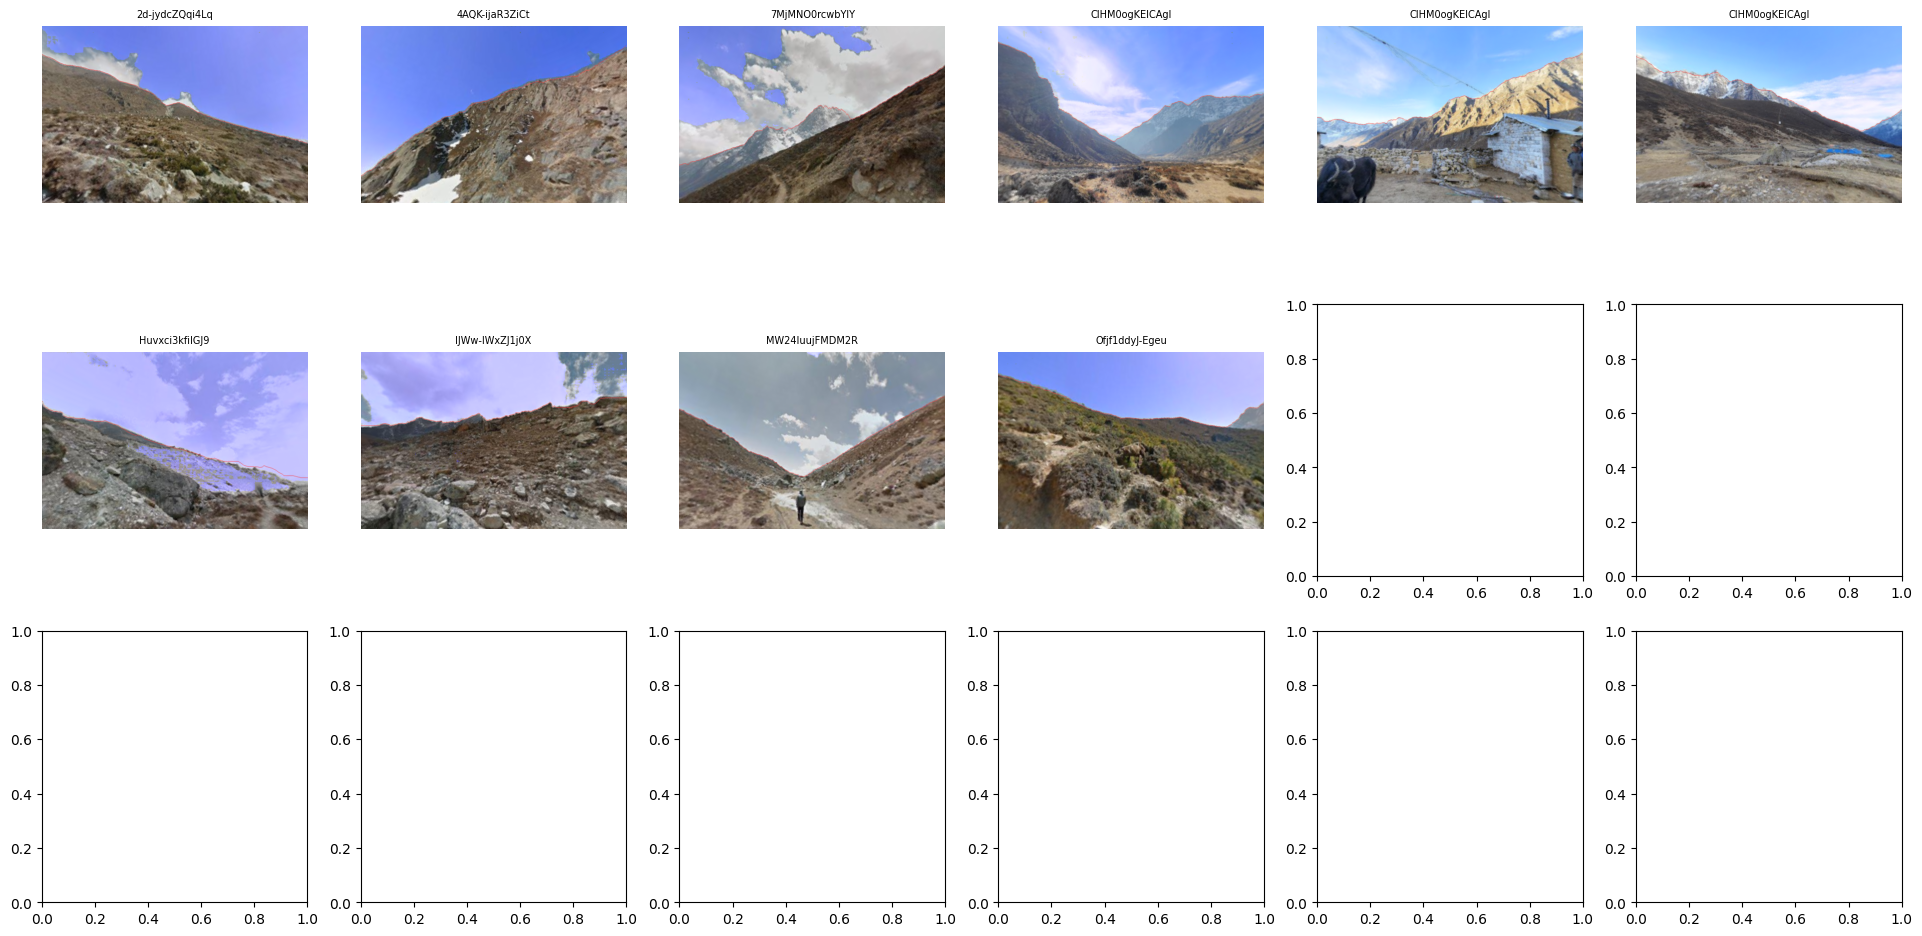

In [31]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import sys

sys.path.insert(0, str(REPO))
from scripts.fixes_eval import mask_from_ann

ann = json.load(open(REPO / 'data/street_view/annotations.json'))['annotations']
gt = json.load(open(REPO / 'data/street_view/ground_truth.json'))
sids = sorted([s for s in ann if s in gt])[:17]

IMAGE_DIR = REPO / 'data/street_view/images'
MASK_DIR_A = CKPT_DIR / 'avenue_a_masks'

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for i, sid in enumerate(sids):
    ax = axes[i]
    img = Image.open(IMAGE_DIR / f'{sid}.png')
    ann_mask, ycol = mask_from_ann(ann[sid])
    sam_mask = np.array(Image.open(MASK_DIR_A / f'{sid}.png'))

    img_arr = np.array(img)
    overlay = img_arr.copy()
    H, W = img_arr.shape[:2]

    # SAM2 sky: blue tint where sky=0
    sky_region = sam_mask == 0
    overlay[sky_region, 2] = np.clip(overlay[sky_region, 2].astype(int) + 80, 0, 255).astype(np.uint8)

    # Annotated skyline boundary: red dots
    if ycol is not None:
        for c in range(0, W, 2):
            row = int(ycol[c])
            for dr in range(-1, 2):
                rr = row + dr
                if 0 <= rr < H:
                    overlay[rr, c] = [255, 50, 50]

    ax.imshow(overlay)
    ax.set_title(sid[:14], fontsize=7)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('SAM2 Masks (blue sky) vs Annotated Skyline (red dots)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/sam2_vs_annotated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/sam2_vs_annotated.png')


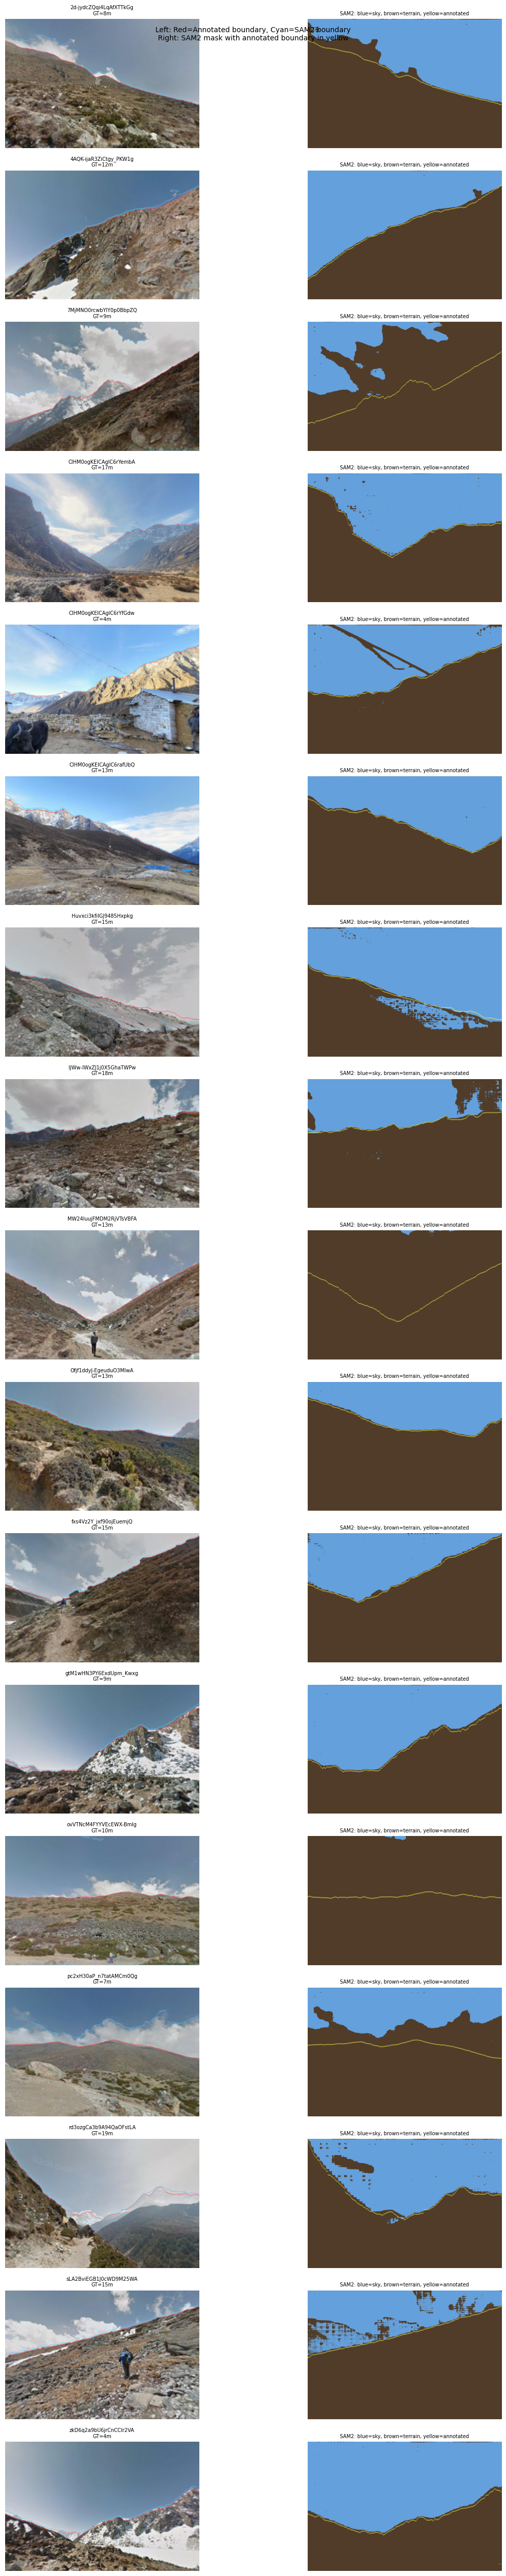

In [9]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/sam2_vs_annotated.png', width=1400))


In [10]:
import json, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

DRIVE = Path('/content/drive/MyDrive')
CKPT = DRIVE / 'avenue_checkpoints'
ann = json.load(open(DRIVE / 'street_view/annotations.json'))['annotations']
gt = json.load(open(DRIVE / 'street_view/ground_truth.json'))
sids = sorted([s for s in ann if s in gt and (CKPT/'avenue_a_masks'/f'{s}.png').exists()])
H, W = 720, 1080

def ann_ycol(pts):
    xs = np.array([p[0] for p in pts], float); ys = np.array([p[1] for p in pts], float)
    o = np.argsort(xs); xs, ys = xs[o], ys[o]
    if np.unique(xs).size < 2: return np.full(W, H)
    return np.array([int(np.interp(x, xs, ys)) if xs[0] <= x <= xs[-1] else H for x in range(W)])

def sam_ycol(mask):
    return np.array([int(np.where(mask[:,c]==0)[0][-1]+1) if (mask[:,c]==0).any() else H for c in range(W)])

def line(img, yc, color):
    o = img.copy()
    for c in range(0, W, 2):
        r = min(H-1, max(0, int(yc[c])))
        for d in range(-2, 3):
            rr = r+d
            if 0 <= rr < H: o[rr, c] = color
    return o

# Pick 4 diverse samples
stds = [(s, np.std(np.load(CKPT/'avenue_a_profiles'/f'{s}.npy'))) for s in sids]
stds.sort(key=lambda x: x[1])
pick = [stds[2][0], stds[7][0], stds[12][0], stds[-2][0]]

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
for i, sid in enumerate(pick):
    img = np.array(Image.open(DRIVE/'street_view/images'/f'{sid}.png'))
    mask = np.array(Image.open(CKPT/'avenue_a_masks'/f'{sid}.png'))
    ayc, sy = ann_ycol(ann[sid]), sam_ycol(mask)

    vis = line(img.copy(), ayc, [255,60,60])
    vis = line(vis, sy, [50,220,255])
    axes[i,0].imshow(vis)
    axes[i,0].set_title(f'{sid}\nGT={gt[sid]["closest_viewpoint_dist_m"]:.0f}m', fontsize=8)
    axes[i,0].axis('off')

    mv = np.zeros((H,W,3), np.uint8)
    mv[mask==0] = [80,140,200]; mv[mask>0] = [60,50,35]
    mv = line(mv, ayc, [255,220,50])
    axes[i,1].imshow(mv)
    axes[i,1].set_title('SAM2 mask + yellow=annotated boundary', fontsize=8)
    axes[i,1].axis('off')

plt.tight_layout()
plt.savefig('/content/sam2_detail.png', dpi=100, bbox_inches='tight')
plt.close()
print('Done')


Done


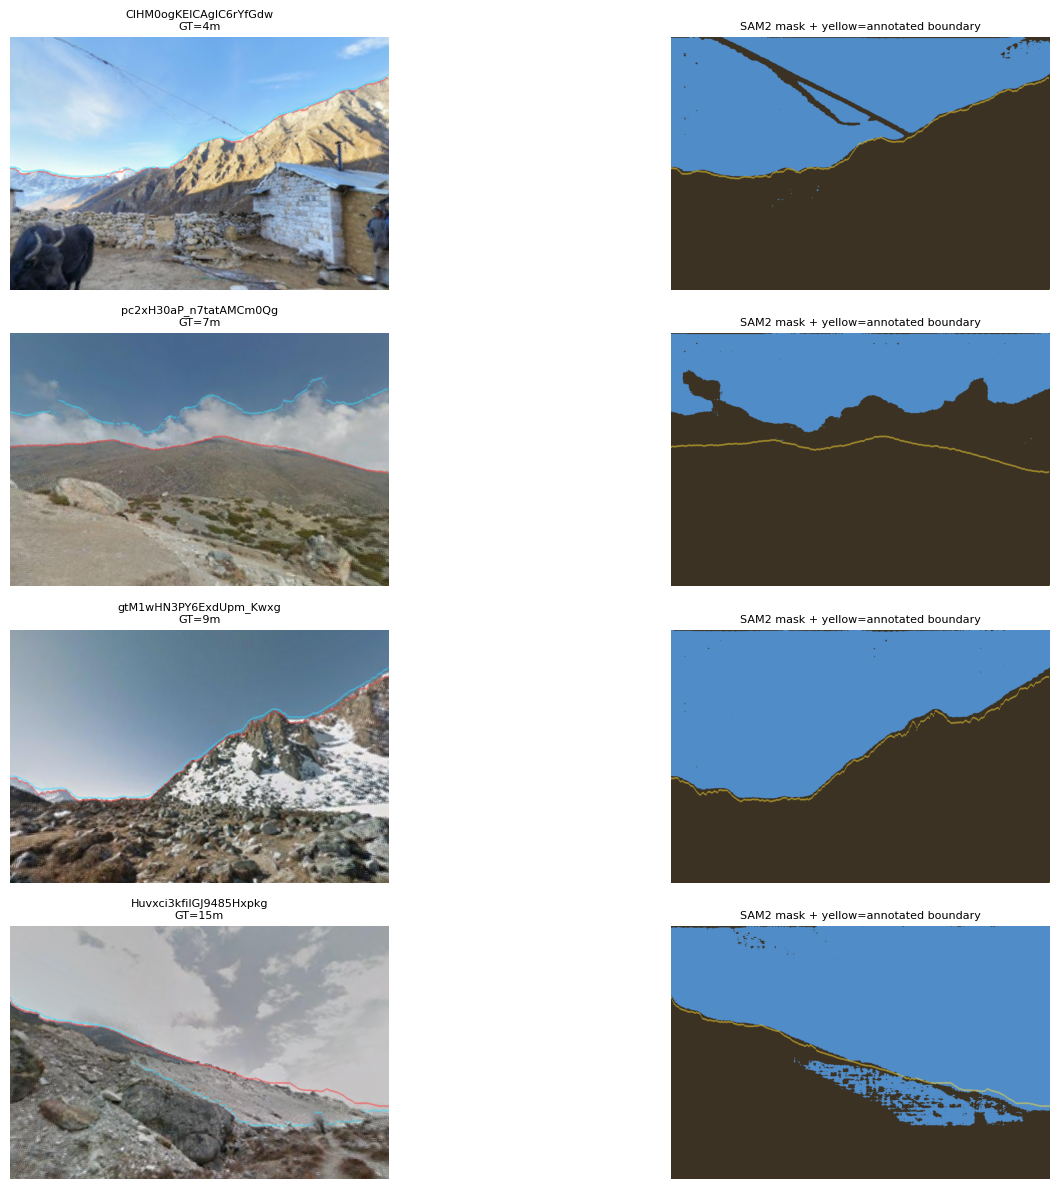

In [11]:
from IPython.display import Image as D, display
D('/content/sam2_detail.png', width=1200)
